In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

## Task 1: Data Exploration

In [38]:
titanic = sns.load_dataset("titanic")
print(titanic.head())
print(titanic.shape)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)


In [39]:
print(titanic.dtypes)
numerical=titanic.select_dtypes(include=["int64", "float64"]).columns
categorical=titanic.select_dtypes(include=["object","category"]).columns
print(f"Numerical columns: {numerical.to_list()}")
print(f"Categorival columns: {categorical.to_list()}")

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object
Numerical columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorival columns: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']


In [40]:
missing_count=titanic.isna().sum()
print(missing_count)
missing_percent=(missing_count/len(titanic))*100
print("Percentage of missing values:")
print(missing_percent)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
Percentage of missing values:
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [41]:
survival_rate = titanic['survived'].mean()
print(f"Survival Rate: {survival_rate:.2%}")
if 0.45 <= survival_rate <= 0.55:
    print("Status: Balanced Data")
elif 0.30 <= survival_rate < 0.45 or 0.55 < survival_rate <= 0.70:
    print("Status: Moderately Imbalanced")
else:
    print("Status: Highly Imbalanced")

Survival Rate: 38.38%
Status: Moderately Imbalanced


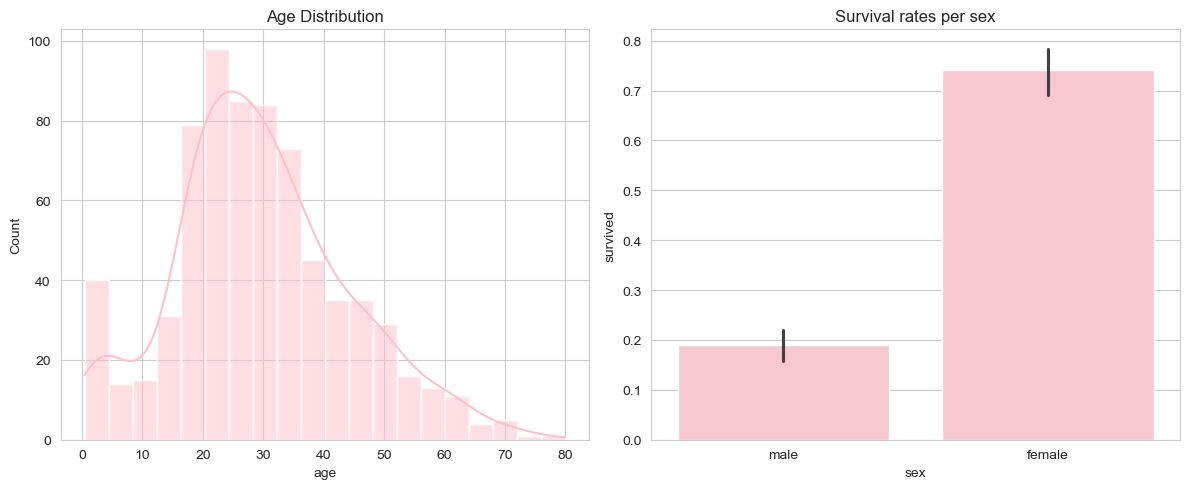

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=titanic, x="age", kde=True, ax=axes[0], color="pink")
axes[0].set_title("Age Distribution")
sns.barplot(data=titanic, x="sex", y="survived", ax=axes[1], color="pink")
axes[1].set_title("Survival rates per sex")
plt.tight_layout()
plt.show()

The dataset consists of 891 rows and 15 columns, containing both numerical (e.g., age, fare) and categorical (e.g., sex, pclass, embarked) variables. The overall survival rate is 38.38%, indicating that the data is moderately imbalanced. Most passengers are between 20 and 40 years old, with a slight peak observed among children. Furthermore, the survival probability for females is significantly higher than for males, suggesting that the 'sex' variable will serve as a strong predictor for the model.

## Task 2: Feature Engineering

In [43]:
titanic["age"]=titanic["age"].fillna(titanic["age"].median())
titanic["embarked"]=titanic["embarked"].fillna(titanic["embarked"].mode()[0])
titanic=titanic.drop(["deck"],axis=1)
print(titanic.isna().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [44]:
titanic["sex"]=titanic["sex"].map({"male":1, "female":0})
titanic=pd.get_dummies(titanic,columns=["embarked"],prefix="embarked")
print(titanic[['sex', 'embarked_C', 'embarked_Q', 'embarked_S']].head())

   sex  embarked_C  embarked_Q  embarked_S
0    1       False       False        True
1    0        True       False       False
2    0       False       False        True
3    0       False       False        True
4    1       False       False        True


In [45]:
titanic["family_size"]=titanic["sibsp"]+titanic["parch"]+1
titanic["is_alone"] = np.where(titanic["family_size"] == 1, 1, 0)
print(titanic[['sibsp', 'parch', 'family_size', 'is_alone']].head())

   sibsp  parch  family_size  is_alone
0      1      0            2         0
1      1      0            2         0
2      0      0            1         1
3      1      0            2         0
4      0      0            1         1


In [46]:
titanic=titanic.drop(["alive", "who", "adult_male", "embark_town", "class", "alone"],axis=1)

In [47]:
print(titanic)

     survived  pclass  sex   age  sibsp  parch     fare  embarked_C  \
0           0       3    1  22.0      1      0   7.2500       False   
1           1       1    0  38.0      1      0  71.2833        True   
2           1       3    0  26.0      0      0   7.9250       False   
3           1       1    0  35.0      1      0  53.1000       False   
4           0       3    1  35.0      0      0   8.0500       False   
..        ...     ...  ...   ...    ...    ...      ...         ...   
886         0       2    1  27.0      0      0  13.0000       False   
887         1       1    0  19.0      0      0  30.0000       False   
888         0       3    0  28.0      1      2  23.4500       False   
889         1       1    1  26.0      0      0  30.0000        True   
890         0       3    1  32.0      0      0   7.7500       False   

     embarked_Q  embarked_S  family_size  is_alone  
0         False        True            2         0  
1         False       False            2 

## Task 3: Feature Scaling & Selection

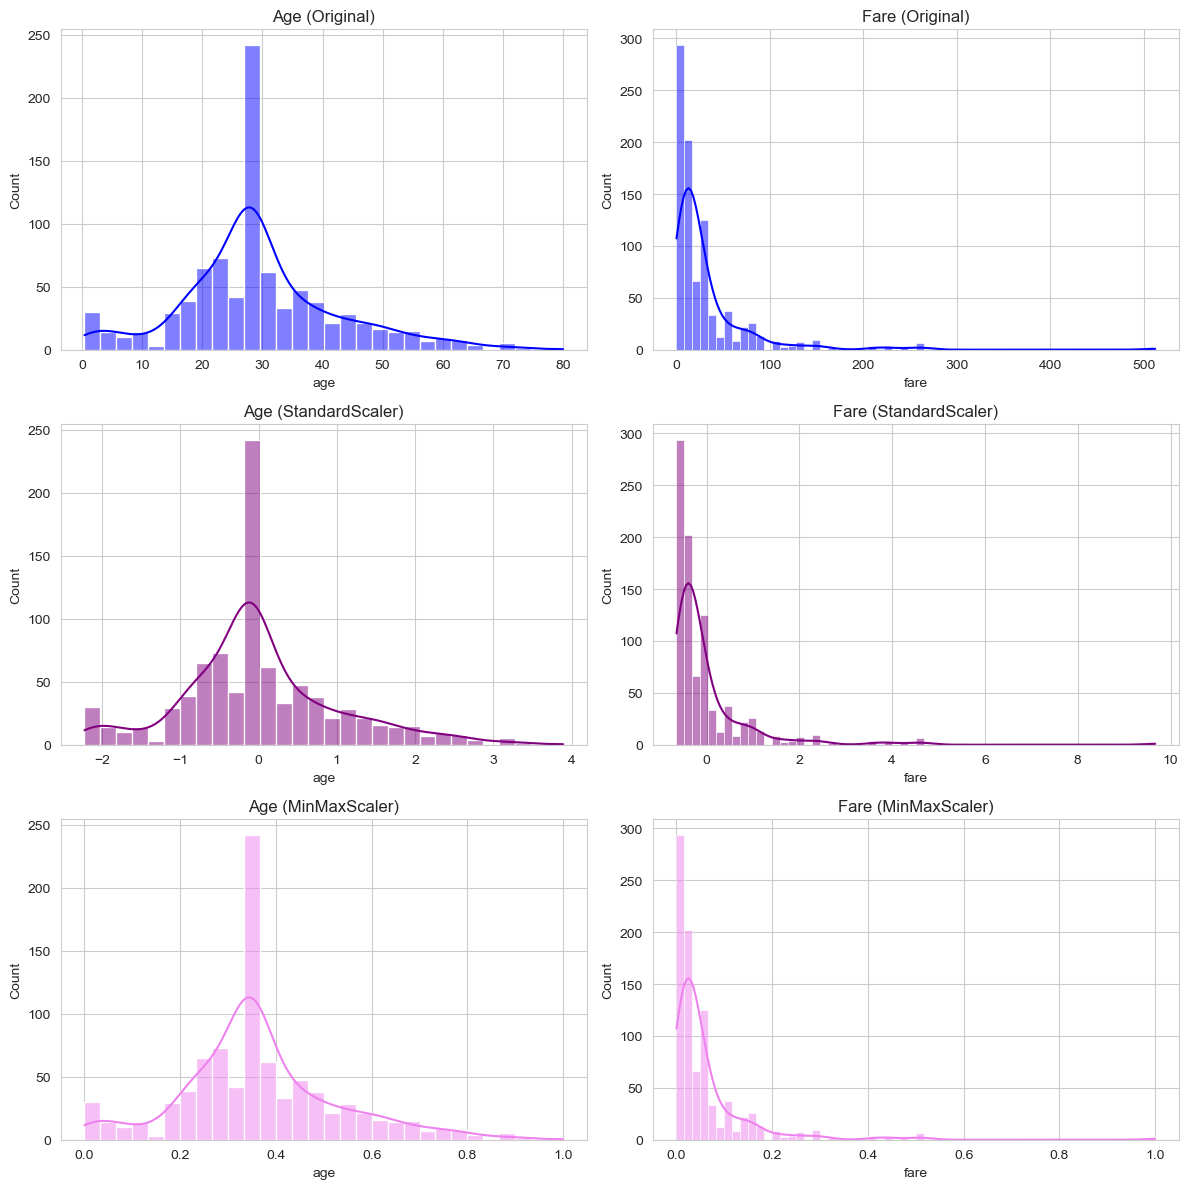

In [48]:
scale_cols=["age","fare"]
standard_scaler=StandardScaler()
min_max_scaler=MinMaxScaler()
titanic_ss=titanic.copy()
titanic_mms=titanic.copy()
titanic_ss[scale_cols] = standard_scaler.fit_transform(titanic[scale_cols])
titanic_mms[scale_cols] = min_max_scaler.fit_transform(titanic[scale_cols])
fig,axes=plt.subplots(3,2,figsize=(12,12))
sns.histplot(titanic['age'], kde=True, ax=axes[0, 0], color='blue').set_title("Age (Original)")
sns.histplot(titanic['fare'], kde=True, ax=axes[0, 1], color='blue').set_title("Fare (Original)")
sns.histplot(titanic_ss['age'], kde=True, ax=axes[1, 0], color='purple').set_title("Age (StandardScaler)")
sns.histplot(titanic_ss['fare'], kde=True, ax=axes[1, 1], color='purple').set_title("Fare (StandardScaler)")
sns.histplot(titanic_mms['age'], kde=True, ax=axes[2, 0], color='violet').set_title("Age (MinMaxScaler)")
sns.histplot(titanic_mms['fare'], kde=True, ax=axes[2, 1], color='violet').set_title("Fare (MinMaxScaler)")
plt.tight_layout()
plt.show()

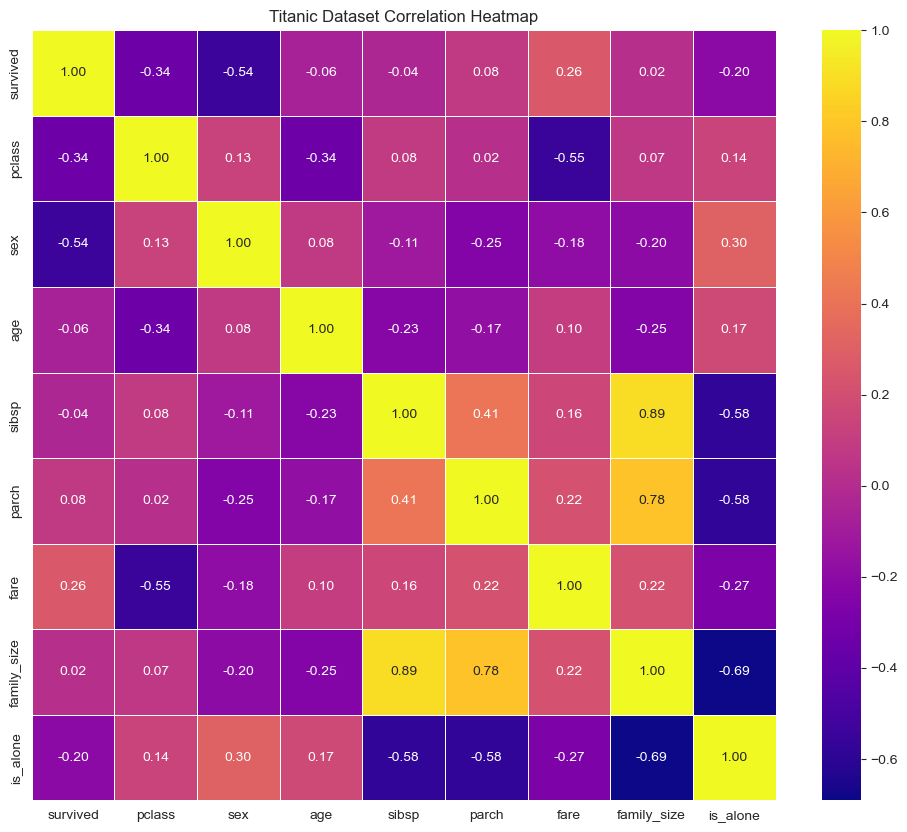

Correlation with Survived:
survived       1.000000
fare           0.257307
parch          0.081629
family_size    0.016639
sibsp         -0.035322
age           -0.064910
is_alone      -0.203367
pclass        -0.338481
sex           -0.543351
Name: survived, dtype: float64


In [49]:
corr_matrix=titanic.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='plasma', fmt=".2f", linewidths=0.5)
plt.title("Titanic Dataset Correlation Heatmap")
plt.show()
target_corr = corr_matrix['survived'].sort_values(ascending=False)
print("Correlation with Survived:")
print(target_corr)

In [50]:
correlations = titanic.select_dtypes(include=[np.number]).corr()['survived'].abs()
top_features = correlations[correlations >= 0.1].sort_values(ascending=False)
print("Selected Features (Absolute Correlation >= 0.1):")
print(top_features)

Selected Features (Absolute Correlation >= 0.1):
survived    1.000000
sex         0.543351
pclass      0.338481
fare        0.257307
is_alone    0.203367
Name: survived, dtype: float64


Based on the correlation results, the features sex, pclass, fare, and is_alone were selected as the primary predictors, as they all exceed the absolute correlation threshold of 0.1. Sex shows the strongest relationship ($r \approx 0.54$), confirming that gender was a critical factor in survival. Interestingly, age did not meet the 0.1 threshold; however, this is likely because the relationship between age and survival is non-linear (with both children and the elderly being prioritized), which linear correlation metrics sometimes fail to capture fully. While I will focus on the highest-correlated features for this task, keeping 'age' would be justifiable in a more complex model to capture these vital patterns.

## Task 4: Dimensionality Reduction

In [51]:
features = titanic.select_dtypes(include=[np.number]).columns.drop('survived')
X = titanic[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("Standardized Data (First 5 rows):")
print(X_scaled_df.head())

Standardized Data (First 5 rows):
     pclass       sex       age     sibsp     parch      fare  family_size  \
0  0.827377  0.737695 -0.565736  0.432793 -0.473674 -0.502445     0.059160   
1 -1.566107 -1.355574  0.663861  0.432793 -0.473674  0.786845     0.059160   
2  0.827377 -1.355574 -0.258337 -0.474545 -0.473674 -0.488854    -0.560975   
3 -1.566107 -1.355574  0.433312  0.432793 -0.473674  0.420730     0.059160   
4  0.827377  0.737695  0.433312 -0.474545 -0.473674 -0.486337    -0.560975   

   is_alone  
0 -1.231645  
1 -1.231645  
2  0.811922  
3 -1.231645  
4  0.811922  


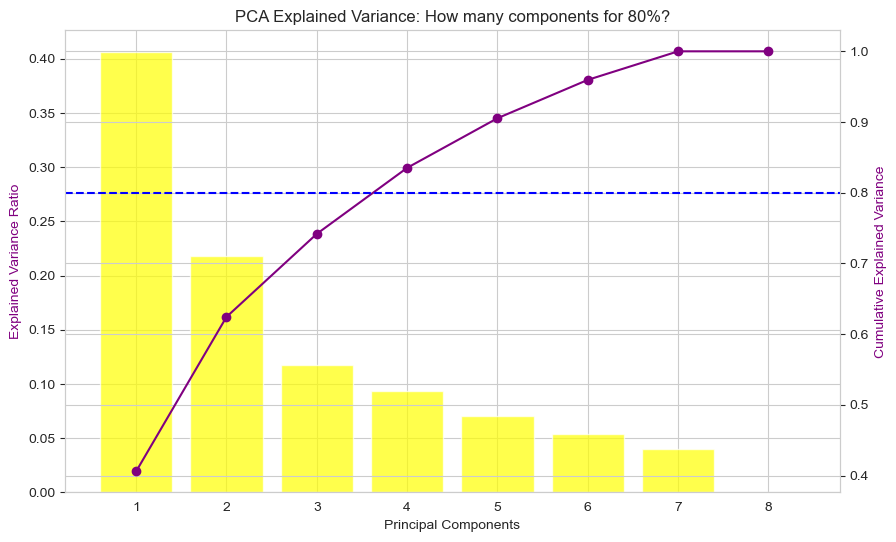

At least 80% of variance is captured by: 4 components


In [52]:
pca = PCA()
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='yellow', label='Individual')
ax1.set_xlabel('Principal Components')
ax1.set_ylabel('Explained Variance Ratio', color='purple')
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='purple', label='Cumulative')
ax2.set_ylabel('Cumulative Explained Variance', color='purple')
ax2.axhline(y=0.80, color='blue', linestyle='--')
plt.title('PCA Explained Variance: How many components for 80%?')
plt.show()
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"At least 80% of variance is captured by: {n_components_80} components")

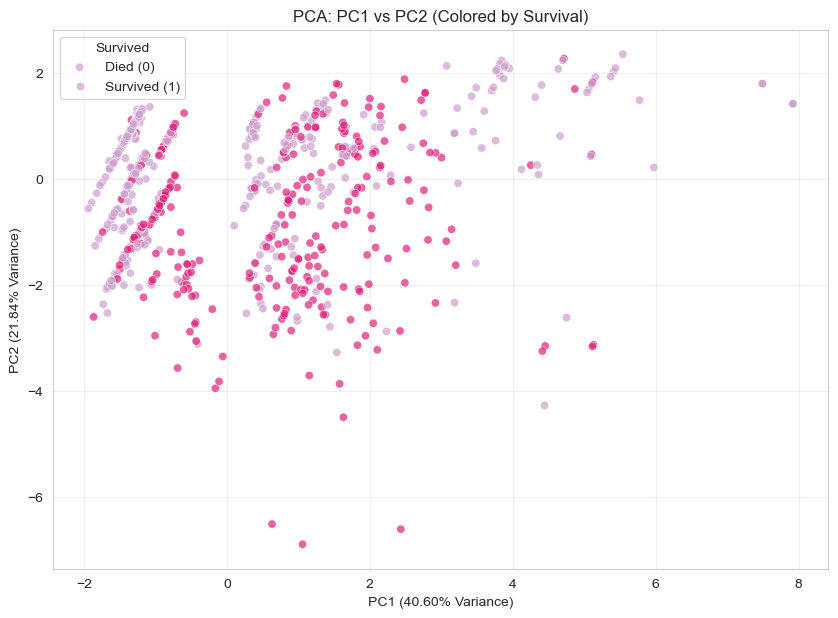

In [53]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['survived'] = titanic['survived'].values
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='survived', data=pca_df, palette='PuRd', alpha=0.7)
plt.title('PCA: PC1 vs PC2 (Colored by Survival)')
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.2%} Variance)')
plt.legend(title='Survived', labels=['Died (0)', 'Survived (1)'])
plt.grid(True, alpha=0.3)
plt.show()

**Does PCA help separate the classes?**

It is clearly evident from the scatter plot that PCA does not help in separating the classes (0 and 1). The data points exhibit a heavy overlap, meaning that the survivors and non-survivors are completely mixed within the same principal component structures. This indicates that the maximum variance captured by PCA is not aligned with the target variable ('survived'). In other words, the primary directions of variance in this dataset do not correspond to the factors that determine survival.

**Would you use PCA as a preprocessing step for this dataset?**

The plot proves that reducing the dataset to just two components (PC1 and PC2) does not yield any useful results for classification. On the contrary, applying PCA as a preprocessing step leads to the loss of critical information (fine details) without providing any clear advantage in class separation. Working with the original features (such as sex, fare, and pclass) is significantly better than using these mixed PCA components, as the original feature space maintains high interpretability and captures the survival logic much more effectively.